## Семинар 11. Advanced GB techniques

Раньше для использования градиентного бустинга необходимо было самостоятельно имплементировать алгоритм. Этим занимались и в крупных корпорациях, которые использовали машинное обучение в своих задачах (например, Microsoft и Яндекс). Некоторые из этих модифицированных имплементаций вышли в open osurce и чаще всего именно они используются на практике. В настоящее время наиболее популярные следующие реализации:
* XGboost + подбор гиперпараметров
* CatBoost + SHAP
* LightGBM

!["История"](https://github.com/hse-ds/iad-intro-ds/blob/master/2023/seminars/sem15_boosting_part2/bst.png?raw=1)

## 1. XGboost + подбор гиперпараметров

Код по xgboost основан на статье https://www.analyticsvidhya.com/blog/2016/03/complete-guide-parameter-tuning-xgboost-with-codes-python/

Основные особенности xgboost:
* базовый алгоритм приближает направление, посчитанное с учетом второй производной функции потерь

* функционал регуляризуется – добавляются штрафы за количество листьев и за норму коэффициентов

* при построении дерева используется критерий информативности, зависящий от оптимального вектора сдвига

* критерий останова при обучении дерева также зависит от оптимального сдвига

Почитать подробнее тут: https://github.com/esokolov/ml-course-hse/blob/master/2020-fall/lecture-notes/lecture10-ensembles.pdf

In [6]:
#!pip3 install xgboost
!brew install libomp

==> Fetching downloads for: libomp
⠋ Bottle Manifest libomp (22.1.5)⠋ Bottle Manifest libomp (22.1.5)⠙ Bottle Manifest libomp (22.1.5)⠙ Bottle Manifest libomp (22.1.5)⠚ Bottle Manifest libomp (22.1.5)⠚ Bottle Manifest libomp (22.1.5)⠞ Bottle Manifest libomp (22.1.5)⠞ Bottle Manifest libomp (22.1.5)⠖ Bottle Manifest libomp (22.1.5)⠖ Bottle Manifest libomp (22.1.5)⠦ Bottle Manifest libomp (22.1.5)⠦ Bottle Manifest libomp (22.1.5)⠴ Bottle Manifest libomp (22.1.5)⠴ Bottle Manifest libomp (22.1.5)⠲ Bottle Manifest libomp (22.1.5)⠲ Bottle Manifest libomp (22.1.5)⠳ Bottle Manifest libomp (22.1.5)                    Downloading   4.1KB/-------⠳ Bottle Manifest libomp (22.1.5)                    Downloading   8.2KB/-------⠓ Bottle Manifest libomp (22.1.5)                    Downloading  12.3KB/-------✔︎ Bottle Manifest libomp (22.1.5)                    Downloaded   12.4KB/ 12.4KB
⠋ Bottle libomp (22.1.5)⠋ Bottle libomp (22.1.5)⠙ Bottle libomp (22.1.5)⠙ Bottle libomp (22.1.5)⠚ Bottle libomp (22

### **Разбор основных гиперпараметров XGBoost**  

| Параметр            | Значение в коде | Описание |
|----------------------|----------------|----------|
| `learning_rate` (eta) | `0.1`          | Шаг градиентного бустинга. Чем меньше, тем точнее модель, но требуется больше деревьев. |
| `n_estimators`       | `150`          | Количество деревьев (итераций бустинга). Можно подбирать через `early_stopping`. |
| `objective`          | `"binary:logistic"` | Функция потерь для бинарной классификации. Для регрессии: `"reg:squarederror"`. |
| `nthread`            | `-1`           | Количество ядер CPU (-1 = все доступные). |
| `seed`               | `27`           | Фиксирует случайность для воспроизводимости. |
|----------------------|----------------|----------|
| `max_depth`          | по умолчанию `6` | Максимальная глубина дерева. Уменьшение снижает риск переобучения. |
| `min_child_weight`   | по умолчанию `1` | Минимальная сумма весов объектов в листе. Большие значения предотвращают переобучение. |
| `scale_pos_weight`   | `1`            | Балансировка классов. Например, `sum(negative) / sum(positive)` для дисбаланса. |
|----------------------|----------------|----------|
| `gamma`              | по умолчанию `0` | Минимальное улучшение loss для разделения узла. Увеличивает устойчивость. |
| `subsample`          | по умолчанию `1` | Доля случайных объектов для каждого дерева (аналог `bagging`). |
| `colsample_bytree`   | по умолчанию `1` | Доля случайных признаков для каждого дерева. |
| `reg_alpha` (alpha)  | по умолчанию `0` | L1-регуляризация (лассо) на веса. |
| `reg_lambda` (lambda)| по умолчанию `1` | L2-регуляризация (ридж) на веса. |
|----------------------|----------------|----------|
| `booster`            | |`"gbtree"` (деревья), `"gblinear"` (линейная модель), `"dart"` (Dropout Additive Regression Trees). |


---

### `XGBClassifier`

```python
model_xgb = XGBClassifier(...)
```

- **Ключевые методы**:  
  - `.fit()` — обучение на данных.  
  - `.predict()` — предсказание классов.  
  - `.predict_proba()` — вероятности классов.  
  - `.get_booster()` — доступ к внутренней структуре деревьев.  

###  `xgb.cv` (кросс-валидация)

```python
cvresult = xgb.cv(
    xgb_param, 
    xgtrain, 
    num_boost_round=alg.get_params()["n_estimators"],
    nfold=cv_folds,
    metrics="auc",
    early_stopping_rounds=early_stopping_rounds,
)
```
- **Назначение**: Оценка модели с кросс-валидацией.  
- **Параметры**:  
  - `nfold=5` — число фолдов.  
  - `metrics="auc"` — метрика для оценки.  
  - `early_stopping_rounds=50` — остановка, если качество не растёт 50 итераций.  

---

In [7]:
import os

import numpy as np
import pandas as pd
from matplotlib import pylab as plot

%pylab inline

import xgboost as xgb
from xgboost.sklearn import XGBClassifier

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['plot']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


Рассмотрим применение данной реализации на примере задачи классификации: по различным характеристикам клиента попытаемся определить, выплатит он долг или нет.

In [75]:
X_train = pd.read_csv("train_small.csv")
X_test  = pd.read_csv("test_small.csv")
len(X_train), len(X_test)

(24365, 10443)

In [76]:
X_train.sample(5)

,Existing_EMI,Loan_Amount_Applied,Loan_Tenure_Applied,Monthly_Income,Var4,Var5,Age,EMI_Loan_Submitted_Missing,Interest_Rate_Missing,Loan_Amount_Submitted_Missing,...,Var2_4,Var2_5,Var2_6,Mobile_Verified_0,Mobile_Verified_1,Source_0,Source_1,Source_2,Disbursed,ID
20129,0.0,500000.0,4.0,12200,1,0,32,1,1,1,...,0,0,1,1,0,1,0,0,0.0,67310
5311,7000.0,200000.0,5.0,10000,1,0,34,1,1,1,...,0,0,1,1,0,1,0,0,0.0,79417
3103,0.0,0.0,0.0,18500,5,1,23,0,0,0,...,0,0,1,0,1,1,0,0,0.0,56478
3931,0.0,0.0,0.0,27000,5,5,29,0,0,0,...,0,0,1,0,1,1,0,0,0.0,70745
19175,5550.0,200000.0,3.0,18500,5,2,26,0,0,0,...,0,0,0,0,1,0,0,1,0.0,41782


Вспомним, что для того, чтобы бустинг показал хорошее качество и не переобучился, необходимо аккуратно подобрать его гиперпараметры. 

Алгоритм подбора гиперпараметров может быть следующим:

* Выбираем относительно большую learning_rate ($ \eta \in [0.05, 0.3]$), подбираем оптимальное число деревьев для выбранного $ \eta $

* Настраиваем параметры деревьев, начиная с самых значимых (max_depth, min_child_weight, gamma, subsample, colsample_bytree)

* Настраиваем регуляризации ($ \lambda, \alpha $)

* Уменьшаем learning_rate, пропорционально увеличиваем число деревьев

In [77]:
model_xgb = XGBClassifier(
    learning_rate=0.1,            # Шаг бустинга (уменьшает вклад каждого дерева, предотвращая переобучение)
    n_estimators=150,             # Количество деревьев 
    # Если используется early_stopping, можно задать большое значение, и алгоритм остановится раньше.
    objective="binary:logistic",  # Функция потерь - бинарная классификация
    nthread=-1,                   # Использовать все ядра (-1 = все ядра)
    scale_pos_weight=1,           # Вес для балансировки классов (e.g. sum(negative) / sum(positive))
    seed=27,                      # Фиксирует случайность для воспроизводимости
)

In [78]:
target = "Disbursed"
IDcol = "ID"

In [79]:
X_train["Disbursed"].value_counts(), len(X_train)

(Disbursed
 0.0    23999
 1.0      366
 Name: count, dtype: int64,
 24365)

In [80]:
366/23999

0.015250635443143465

Создадим функцию для моделирования и кросс-валидации

Эта функция делает следующее:
1. обучает модель
2. вычисляет accuracy на тренировочной выборке
3. вычисляет AUC на тренировочной выборке
4. вычисляет AUC на тестовой выборке
5. обновляет n_estimators с помощью встроенной в пакет xgboost функции cv
6. строит диаграмму Feature Importance 

In [81]:
from sklearn import metrics


def modelfit(
    alg,
    dtrain,
    dtest,
    predictors,
    useTrainCV=False,
    cv_folds=5,
    early_stopping_rounds=50,
):
    if useTrainCV:
        # кросс-валидация для подбора n_estimators
        
        xgb_param = alg.get_xgb_params()

        # специальный формат данных для XGBoost 
        xgtrain = xgb.DMatrix(dtrain[predictors].values, label=dtrain[target].values)
        xgtest = xgb.DMatrix(dtest[predictors].values)
        
        cvresult = xgb.cv(
            xgb_param,
            xgtrain,
            num_boost_round=alg.get_params()["n_estimators"],
            nfold=cv_folds, # кол-во фолдов CV
            metrics="auc",  # кросс-валидация с метрикой AUC
            early_stopping_rounds=early_stopping_rounds, # если AUC не растёт 50 раундов, обучение останавливается
        )
        alg.set_params(n_estimators=cvresult.shape[0]) # итоговое число деревьев после ранней остановки

    # Fit the algorithm on the data
    alg.fit(dtrain[predictors], dtrain["Disbursed"])#, eval_metric="auc")

    # Predict training set:
    dtrain_predictions = alg.predict(dtrain[predictors])
    dtrain_predprob = alg.predict_proba(dtrain[predictors])[:, 1]

    # Print model report:
    print("\nModel Report")
    print(
        "Accuracy : %.4g"
        % metrics.accuracy_score(dtrain["Disbursed"].values, dtrain_predictions)
    )
    print(
        "AUC Score (Train): %f"
        % metrics.roc_auc_score(dtrain["Disbursed"], dtrain_predprob)
    )

    # Predict on testing data:
    dtest["predprob"] = alg.predict_proba(dtest[predictors])[:, 1]
    print(
        "AUC Score (Test): %f"
        % metrics.roc_auc_score(dtest["Disbursed"], dtest["predprob"])
    )

    # get_fscore() — считает, сколько раз признак использовался в деревьях
    feat_imp = pd.Series(alg.get_booster().get_fscore()).sort_values(ascending=False)
    feat_imp.plot(kind="bar", title="Feature Importances")
    plt.ylabel("Feature Importance Score")

Начинаем последовательный подбор параметров при большом learning_rate


Model Report
Accuracy : 0.9855
AUC Score (Train): 0.968005
AUC Score (Test): 0.811314


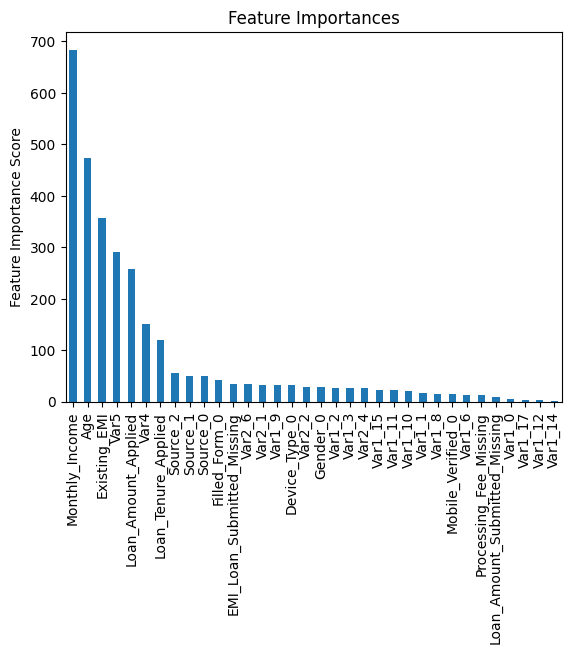

In [82]:
predictors = [x for x in X_train.columns if x not in [target, IDcol]]

modelfit(model_xgb, X_train, X_test, predictors)

Перебираем max_depth и min_child_weight по сетке.

In [83]:
from sklearn.model_selection import GridSearchCV

param_test1 = {"max_depth": range(2, 7, 2), "min_child_weight": range(1, 6, 2)}

gsearch1 = GridSearchCV(
    estimator=model_xgb,
    param_grid=param_test1,
    scoring="roc_auc",  # Оптимизируем AUC
    n_jobs=-1,          # Используем все ядра
    cv=5                # 5-fold кросс-валидация
)

gsearch1.fit(X_train[predictors], X_train[target])

gsearch1.best_params_, gsearch1.best_score_

({'max_depth': 2, 'min_child_weight': 5}, np.float64(0.825645786144474))

Уточняем предсказание

In [84]:
param_test2 = {"max_depth": [3, 4, 5], "min_child_weight": [4, 5, 6]}

gsearch2 = GridSearchCV(
    estimator=model_xgb, param_grid=param_test2, scoring="roc_auc", n_jobs=-1, cv=5
)

gsearch2.fit(X_train[predictors], X_train[target])
gsearch2.best_params_, gsearch2.best_score_

({'max_depth': 3, 'min_child_weight': 4}, np.float64(0.8274114000090442))

Зафиксируем найденный max_depth и min_child_weight

In [85]:
model_xgb.max_depth = 3
model_xgb.min_child_weight = 4

Мы подобрали max_depth и min_child_weight - дальше будем использовать подобранные значения параметров. Подберите по сетке параметр gamma на отрезке от 0 до 1.

In [86]:
param_test3 = {
    'gamma': np.logspace(-3, 0, 5)
}

gsearch3b = GridSearchCV(
    estimator=model_xgb, param_grid=param_test3, scoring='roc_auc', n_jobs=-1, cv=3
)

gsearch3b.fit(X_train[predictors], X_train[target])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...hread=-1, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': array([0.001 ...1778, 1. ])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and

In [87]:
gsearch3b.best_params_, gsearch3b.best_score_

({'gamma': np.float64(1.0)}, np.float64(0.8181367684194814))

Установите в качестве параметра алгоритма подобранyю gamma и посмотрите как изменилось качество.


Model Report
Accuracy : 0.985
AUC Score (Train): 0.866611
AUC Score (Test): 0.832171


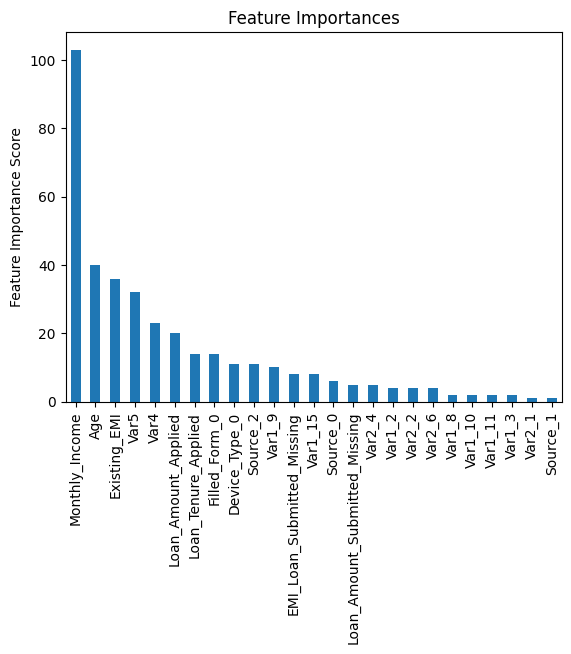

In [88]:
predictors = [x for x in X_train.columns if x not in [target, IDcol]]

model_xgb.gamma = gsearch3b.best_params_['gamma']

modelfit(model_xgb, X_train, X_test, predictors)

Подберите по сетке параметры subsample и colsample_bytree. Используйте значения этих параметров: [0.6, 0.7, 0.8, 0.9, 1.]

In [89]:
test_params4 = {
    'subsample' : [0.6, 0.7, 0.8, 0.9, 1.],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.],
    'colsample_bylevel' : [0.6, 0.7, 0.8, 0.9, 1.]
}

gsearch4b = GridSearchCV(
    estimator=model_xgb, param_grid=test_params4, n_jobs=-1, cv=3, scoring='roc_auc'
)

gsearch4b.fit(X_train[predictors], X_train[target])

gsearch4b.best_params_, gsearch4b.best_score_

({'colsample_bylevel': 0.6, 'colsample_bytree': 1.0, 'subsample': 0.8},
 np.float64(0.8196905884154235))

Подберите параметр регуляризации reg_alpha. Попробуйте [1e-5, 1e-2, 0.1, 1, 100]

In [90]:
test_params5 = {
    'reg_alpha': [1e-5, 1e-2, 0.1, 1, 100]
}

gsearch5b = GridSearchCV(
    estimator=model_xgb,
    param_grid=test_params5,
    n_jobs=-1,
    cv=3,
    scoring='roc_auc'
)

gsearch5b.fit(X_train[predictors], X_train[target])
gsearch5b.best_params_, gsearch5b.best_score_

({'reg_alpha': 0.1}, np.float64(0.8181400258066752))

Запустите обучение и предсказание на найденных параметрах и посмотрите на качество.


Model Report
Accuracy : 0.985
AUC Score (Train): 0.893033
AUC Score (Test): 0.831932


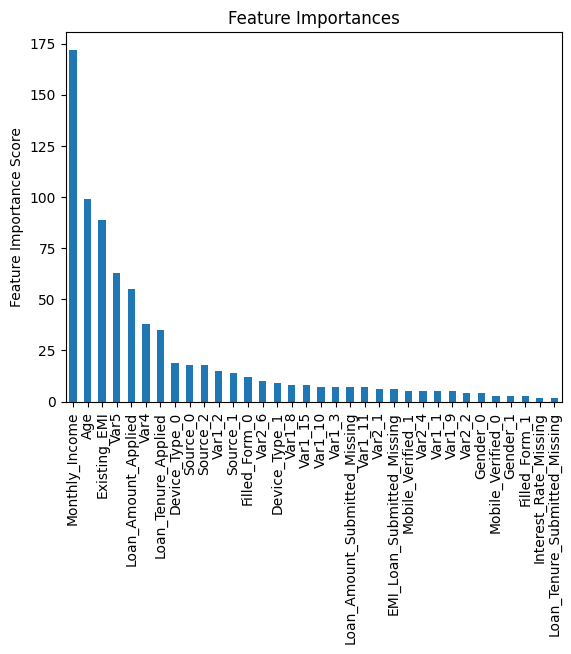

In [91]:
model_xgb.colsample_bylevel = gsearch4b.best_params_['colsample_bylevel']
model_xgb.colsample_bytree = gsearch4b.best_params_['colsample_bytree']
model_xgb.subsample = gsearch4b.best_params_['subsample']
model_xgb.reg_alpha = gsearch5b.best_params_['reg_alpha']

modelfit(model_xgb, X_train, X_test, predictors)

Уменьшите learning_rate до 0.01 и пропорционально увеличьте число деревьев. Все подобранные параметры остаются такими же. Обучите модель и сделайте предсказание. Посмотрите на качество.


Model Report
Accuracy : 0.985
AUC Score (Train): 0.893877
AUC Score (Test): 0.833263


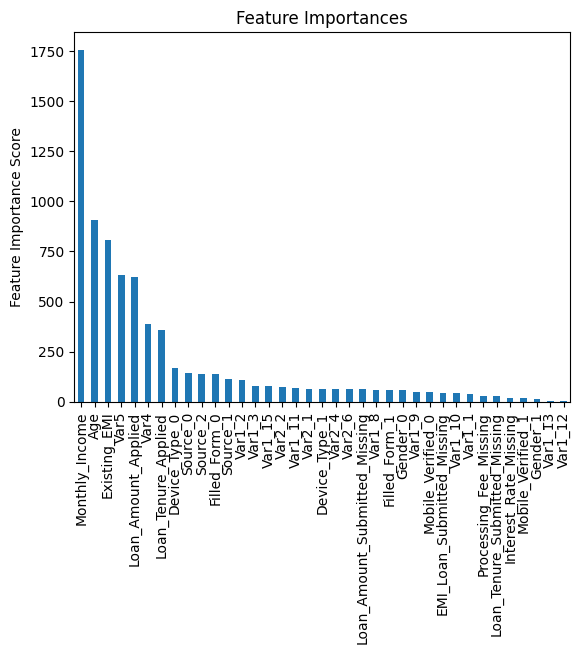

In [92]:
model_xgb.learning_rate = 0.01
model_xgb.n_estimators = model_xgb.n_estimators * 10 
modelfit(model_xgb, X_train, X_test, predictors)

## 2. CatBoost

Ноутбук из официальной документации здесь: https://github.com/catboost/tutorials/blob/master/classification/classification_tutorial.ipynb

Особенности катбуста:

* используются симметричные деревья решений

* для кодирования категориальных признаков используется большой набор методов

* динамический бустинг 

Благодаря использованию симметричных деревьев и динамическому бустингу катбуст гораздо более устойчив к переобучению, чем другие имплементации градиентного бустинга. Поэтому он показывает хорошее качество даже при дефолтных параметрах.

Посмотреть видео про катбуст: https://yandex.ru/video/preview/?filmId=10919886479285152550&from=tabbar&text=catboost+анна+вероника

### Основные гиперпараметры CatBoost 

| **Категория**       | **Параметр**              | **Значения по умолчанию** | **Описание** |
|---------------------|---------------------------|---------------------------|--------------|
| **Основные**        | `iterations`              | 1000                      | Максимальное количество деревьев |
|                     | `learning_rate`           | 0.03                      | Темп обучения (размер шага) |
|                     | `loss_function`           | Зависит от задачи         | Функция потерь (Logloss, RMSE, MultiClass и др.) |
|                     | `eval_metric`             | Автовыбор                 | Метрика оценки (AUC, Accuracy, F1) |
| **Деревья**         | `depth`                   | 6                         | Глубина деревьев |
|                     | `grow_policy`             | SymmetricTree             | Стратегия роста: SymmetricTree, Depthwise, Lossguide |
|                     | `min_data_in_leaf`        | 1                         | Минимальное количество объектов в листе |
|                     | `max_leaves`              | 31                        | Максимальное количество листьев (только для Lossguide) |
| **Регуляризация**   | `l2_leaf_reg`             | 3.0                       | Коэффициент L2-регуляризации |
|                     | `model_size_reg`          | 0.5                       | Штраф за размер модели (меньше → проще модель) |
|                     | `bagging_temperature`     | 1.0                       | Интенсивность бейесовского бэггинга |
| **Категориальные**  | `cat_features`            | -                         | Индексы категориальных признаков |
|                     | `one_hot_max_size`        | 2                         | Порог для one-hot кодирования |
|                     | `max_ctr_complexity`      | 4                         | Максимальная сложность комбинаций категорий |
| **Переобучение**    | `early_stopping_rounds`  | -                         | Ранняя остановка при отсутствии улучшений |
|                     | `od_type`                 | IncToDec                  | Тип детектора переобучения |
|                     | `random_strength`         | 1.0                       | Влияние случайности при выборе разбиений |
| **Производительность** | `thread_count`           | -1 (все ядра)             | Количество потоков |
|                     | `task_type`               | CPU                       | Использование GPU (GPU) |
| **Другие**          | `verbose`                 | 1                         | Уровень логгирования |
|                     | `random_seed`             | 0                         | Seed для воспроизводимости |
|                     | `bootstrap_type`          | MVS                       | Тип бэггинга (Bayesian, Bernoulli, MVS) |

Устанавливаем библиотеки

In [27]:
!pip3 install --upgrade catboost
#!pip3.9 install --upgrade ipywidgets
#!pip3.9 install shap
#!pip3.9 install sklearn
#!pip3.9 install --upgrade matplotlib
#!pip3.9 install --upgrade pandas
!pip3.9 install numpy==1.26.4
!jupyter nbextension enable --py widgetsnbextension


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
zsh:1: command not found: pip3.9
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: console dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert notebook run server troubleshoot trust



In [28]:
from matplotlib import pylab as plt
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/magics/pylab.py:166: UserWarning: pylab import has clobbered these variables: ['plt']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


In [29]:
import os

import numpy as np
import pandas as pd

np.set_printoptions(precision=4)
import catboost
from catboost import *
from catboost import datasets

Считываем данные. Данные содержат только категориальные признаки, причем с большим количеством категорий. Признаки - закодированные характеристики сотрудника и некоторого ресурса, целевая переменная - есть ли у сотрудника доступ к ресурсу.

In [30]:
(train_df, test_df) = catboost.datasets.amazon()

In [31]:
train_df.head()

,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


Готовим данные

In [32]:
y = train_df.ACTION
X = train_df.drop("ACTION", axis=1)

Создаем список категориальных фичей

In [33]:
cat_features = list(range(0, X.shape[1]))
print(cat_features)

[0, 1, 2, 3, 4, 5, 6, 7, 8]


Смотрим на соотношение классов

In [34]:
print("Labels: {}".format(set(y)))
print("Zero count = {}, One count = {}".format(len(y) - sum(y), sum(y)))

Labels: {0, 1}
Zero count = 1897, One count = 30872


В catboost используется абстракция Pool - это объект, который содержит матрицу объект-признак X, вектор ответов, список номеров колонок с категориальными признаками.

In [35]:
pool1 = Pool(data=X, label=y, cat_features=cat_features)

pool2 = Pool(data=X, cat_features=cat_features)

# Fastest way to create a Pool is to create it from numpy matrix.
# This way should be used if you want fast predictions
# or fastest way to load the data in python.

X_prepared = X.values.astype(str).astype(object)
# For FeaturesData class categorial features must have type str

pool3 = Pool(
    data=FeaturesData(cat_feature_data=X_prepared, cat_feature_names=list(X)),
    label=y.values,
)

print("Dataset shape")
print(
    "dataset 1:"
    + str(pool1.shape)
    + "\ndataset 2:"
    + str(pool2.shape)
    + "\ndataset 3: "
    + str(pool3.shape)
)

print("\n")
print("Column names")
print("dataset 1:")
print(pool1.get_feature_names())
print("\ndataset 2:")
print(pool2.get_feature_names())
print("\ndataset 3:")
print(pool3.get_feature_names())

Dataset shape
dataset 1:(32769, 9)
dataset 2:(32769, 9)
dataset 3: (32769, 9)


Column names
dataset 1:
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']

dataset 2:
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']

dataset 3:
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']


Разбиваем данные на train и validation

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, train_size=0.8, random_state=42
)

Выбираем функцию потерь

Для бинарной классификации можем использовать:

* `Logloss`

* `CrossEntropy`

In [37]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(iterations=10, learning_rate=0.1)
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
    verbose=False,
)
print("Model is fitted: " + str(model.is_fitted()))
print("Model params:")
print(model.get_params())

Model is fitted: True
Model params:
{'iterations': 10, 'learning_rate': 0.1}


Печать результатов

In [38]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
)

0:	learn: 0.6189879	test: 0.6185816	best: 0.6185816 (0)	total: 7.96ms	remaining: 71.6ms
1:	learn: 0.5585149	test: 0.5574616	best: 0.5574616 (1)	total: 14.8ms	remaining: 59.3ms
2:	learn: 0.5082799	test: 0.5069499	best: 0.5069499 (2)	total: 19.1ms	remaining: 44.5ms
3:	learn: 0.4660897	test: 0.4643558	best: 0.4643558 (3)	total: 23.1ms	remaining: 34.7ms
4:	learn: 0.4304632	test: 0.4282709	best: 0.4282709 (4)	total: 27.5ms	remaining: 27.5ms
5:	learn: 0.4002849	test: 0.3979354	best: 0.3979354 (5)	total: 31.9ms	remaining: 21.3ms
6:	learn: 0.3745697	test: 0.3720454	best: 0.3720454 (6)	total: 33.9ms	remaining: 14.5ms
7:	learn: 0.3525686	test: 0.3498882	best: 0.3498882 (7)	total: 36.3ms	remaining: 9.07ms
8:	learn: 0.3336944	test: 0.3308677	best: 0.3308677 (8)	total: 38ms	remaining: 4.22ms
9:	learn: 0.3174817	test: 0.3145131	best: 0.3145131 (9)	total: 39.9ms	remaining: 0us

bestTest = 0.3145131058
bestIteration = 9



CatBoostClassifier(iterations=10, learning_rate=0.1)

Визуализация метрик

In [39]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
    verbose=False,
    plot=True,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(iterations=10, learning_rate=0.1)

Сравнение моделей

In [40]:
model1 = CatBoostClassifier(
    learning_rate=0.1, iterations=100, random_seed=0, train_dir="learing_rate_0.1"
)

model2 = CatBoostClassifier(
    learning_rate=0.07, iterations=100, random_seed=0, train_dir="learing_rate_0.07"
)

model1.fit(
    X_train,
    y_train,
    eval_set=(X_validation, y_validation),
    cat_features=cat_features,
    verbose=False,
)
model2.fit(
    X_train,
    y_train,
    eval_set=(X_validation, y_validation),
    cat_features=cat_features,
    verbose=False,
)

CatBoostClassifier(iterations=100, learning_rate=0.07, random_seed=0, train_dir='learing_rate_0.07')

In [42]:
from catboost import MetricVisualizer

MetricVisualizer(["learing_rate_0.1", "learing_rate_0.07"]).start()

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Оптимальное количество деревьев

In [43]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=100,
    random_seed=63,
    learning_rate=0.5,
    #     use_best_model=False
)
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
    verbose=False,
    plot=True,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(iterations=100, learning_rate=0.5, random_seed=63)

In [44]:
print("Tree count: " + str(model.tree_count_))

Tree count: 92


Кросс-валидация

In [45]:
from catboost import cv

params = {}
params["loss_function"] = "Logloss"
params["iterations"] = 80
params["custom_loss"] = "AUC"
params["random_seed"] = 63
params["learning_rate"] = 0.5

cv_data = cv(
    params=params,
    pool=Pool(X, label=y, cat_features=cat_features),
    fold_count=5,
    shuffle=True,
    partition_random_seed=0,
    plot=True,
    stratified=False,
    verbose=False,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Training on fold [0/5]

bestTest = 0.1674879003
bestIteration = 36

Training on fold [1/5]

bestTest = 0.1642588398
bestIteration = 56

Training on fold [2/5]

bestTest = 0.1531042161
bestIteration = 63

Training on fold [3/5]

bestTest = 0.1426916182
bestIteration = 78

Training on fold [4/5]

bestTest = 0.1560519524
bestIteration = 55



In [46]:
cv_data.head()

,iterations,test-Logloss-mean,test-Logloss-std,train-Logloss-mean,train-Logloss-std,test-AUC-mean,test-AUC-std
0,0,0.302367,0.004317,0.302196,0.004517,0.513577,0.030360
1,1,0.226879,0.007618,0.228406,0.005219,0.640026,0.046937
2,2,0.189560,0.005706,0.195723,0.004473,0.797855,0.011978
3,3,0.178061,0.006784,0.186107,0.003632,0.815144,0.010133
4,4,0.171654,0.007401,0.181249,0.002254,0.827182,0.004918


In [47]:
best_value = np.min(cv_data["test-Logloss-mean"])
best_iter = np.argmin(cv_data["test-Logloss-mean"])

print(
    "Best validation LogLoss score, not stratified: {:.4f}±{:.4f} on step {}".format(
        best_value, cv_data["test-Logloss-std"][best_iter], best_iter
    )
)

Best validation LogLoss score, not stratified: 0.1574±0.0094 on step 62


Детектор переобучения

In [48]:
model_with_early_stop = CatBoostClassifier(
    iterations=200, random_seed=63, learning_rate=0.5, early_stopping_rounds=20
)
model_with_early_stop.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
    verbose=False,
    plot=True,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(early_stopping_rounds=20, iterations=200, learning_rate=0.5, random_seed=63)

In [49]:
print(model_with_early_stop.tree_count_)

21


In [50]:
model_with_early_stop = CatBoostClassifier(
    eval_metric="AUC",
    iterations=200,
    random_seed=63,
    learning_rate=0.5,
    early_stopping_rounds=20,
)
model_with_early_stop.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_validation, y_validation),
    verbose=False,
    plot=True,
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(early_stopping_rounds=20, eval_metric='AUC', iterations=200, learning_rate=0.5, random_seed=63)

In [51]:
print(model_with_early_stop.tree_count_)

52


Вычисление метрик качества и выбор порога принятия решения

In [52]:
model = CatBoostClassifier(
    random_seed=63,
    iterations=200,
    learning_rate=0.03,
)
model.fit(X_train, y_train, cat_features=cat_features, verbose=False, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(iterations=200, learning_rate=0.03, random_seed=63)

![](https://habrastorage.org/webt/y4/1q/yq/y41qyqfm9mcerp2ziys48phpjia.png)

In [53]:
import sklearn
from catboost.utils import get_roc_curve
from sklearn import metrics

eval_pool = Pool(X_validation, y_validation, cat_features=cat_features)
curve = get_roc_curve(model, eval_pool)
(fpr, tpr, thresholds) = curve
roc_auc = sklearn.metrics.auc(fpr, tpr)

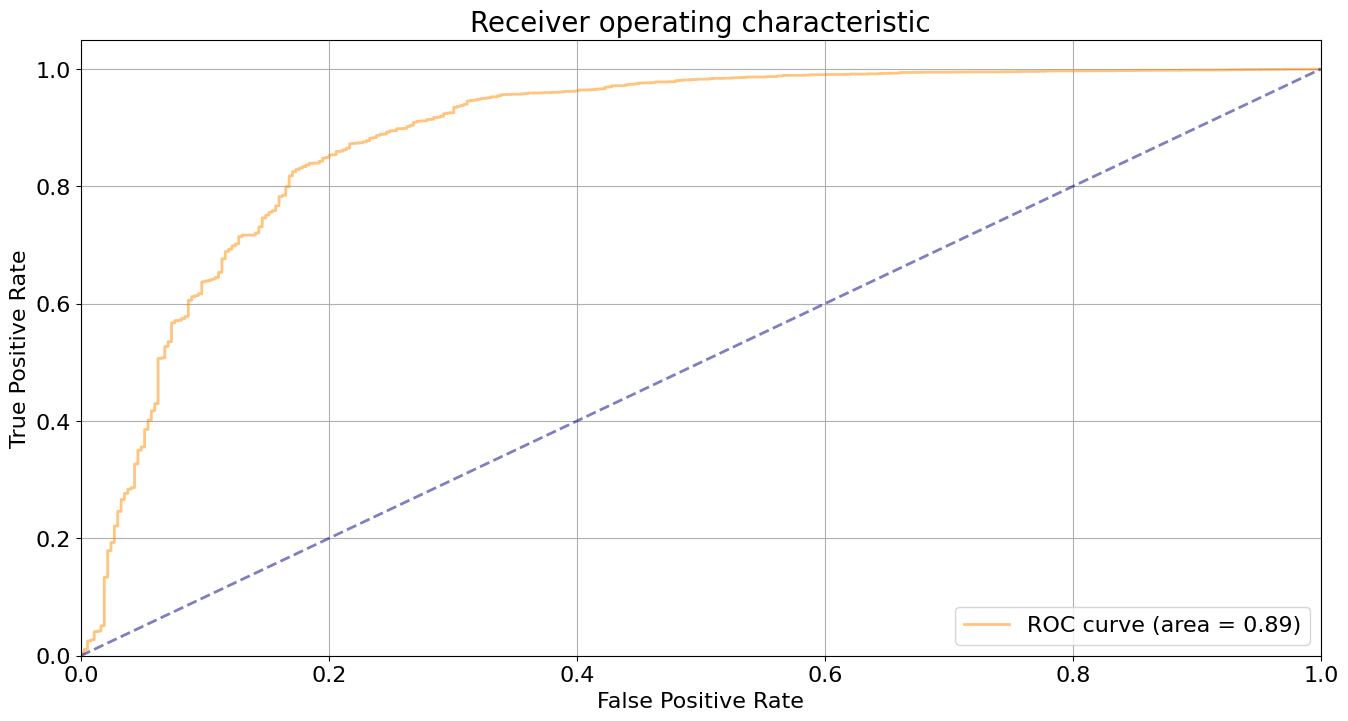

In [54]:
plt.figure(figsize=(16, 8))
lw = 2

plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=lw,
    label="ROC curve (area = %0.2f)" % roc_auc,
    alpha=0.5,
)

plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--", alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)
plt.title("Receiver operating characteristic", fontsize=20)
plt.legend(loc="lower right", fontsize=16)
plt.show()

In [55]:
from catboost.utils import get_fnr_curve, get_fpr_curve

(thresholds, fpr) = get_fpr_curve(curve=curve)
(thresholds, fnr) = get_fnr_curve(curve=curve)

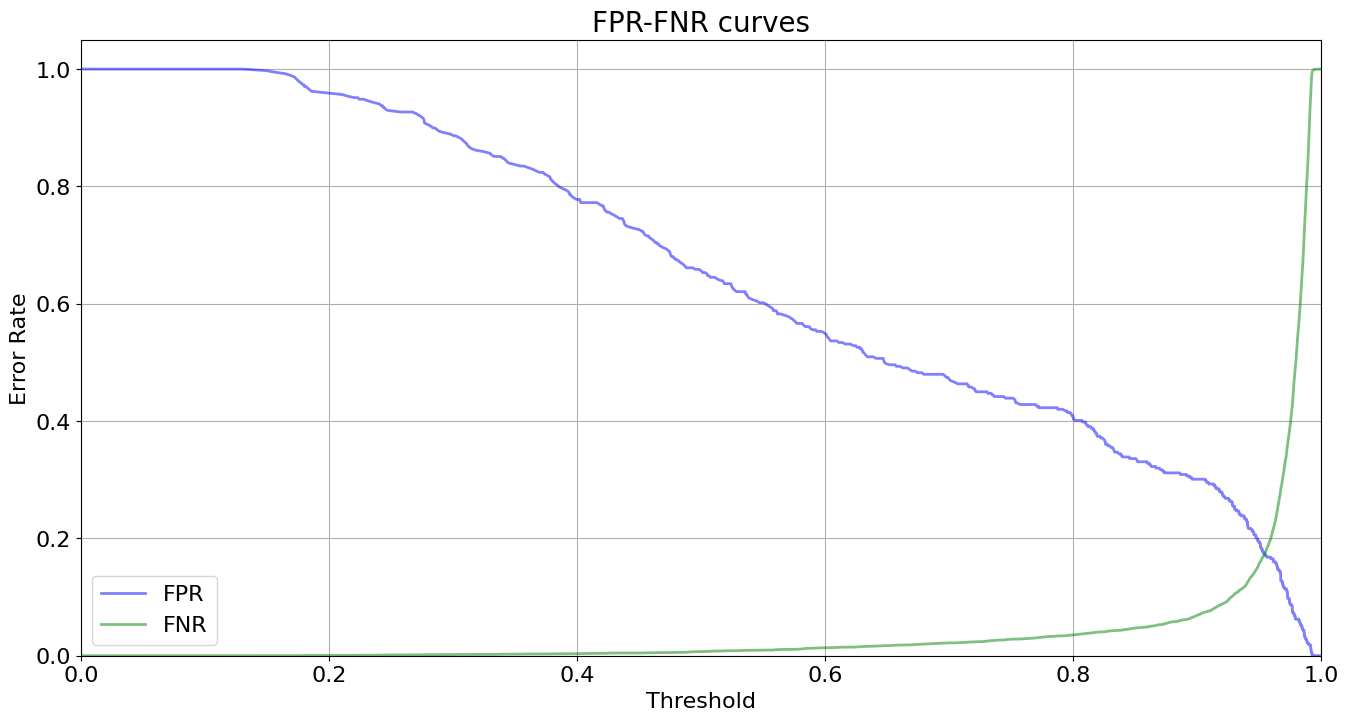

In [56]:
plt.figure(figsize=(16, 8))
lw = 2

plt.plot(thresholds, fpr, color="blue", lw=lw, label="FPR", alpha=0.5)
plt.plot(thresholds, fnr, color="green", lw=lw, label="FNR", alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.xlabel("Threshold", fontsize=16)
plt.ylabel("Error Rate", fontsize=16)
plt.title("FPR-FNR curves", fontsize=20)
plt.legend(loc="lower left", fontsize=16)
plt.show()

In [57]:
from catboost.utils import select_threshold

print(select_threshold(model=model, data=eval_pool, FNR=0.01))
print(select_threshold(model=model, data=eval_pool, FPR=0.01))

0.5589790557061969
0.9922433395240446


Получение предсказаний

In [58]:
print(model.predict_proba(X_validation))

[[0.0114 0.9886]
 [0.0185 0.9815]
 [0.0169 0.9831]
 ...
 [0.0119 0.9881]
 [0.0088 0.9912]
 [0.0139 0.9861]]


In [59]:
print(model.predict(X_validation))

[1 1 1 ... 1 1 1]


Последовательные предсказания

In [60]:
predictions_gen = model.staged_predict_proba(
    data=X_validation, ntree_start=0, ntree_end=5, eval_period=1
)
try:
    for iteration, predictions in enumerate(predictions_gen):
        print("Iteration " + str(iteration) + ", predictions:")
        print(predictions)
except Exception:
    pass

Iteration 0, predictions:
[[0.4794 0.5206]
 [0.4794 0.5206]
 [0.4794 0.5206]
 ...
 [0.4794 0.5206]
 [0.4794 0.5206]
 [0.4794 0.5206]]
Iteration 1, predictions:
[[0.4588 0.5412]
 [0.4588 0.5412]
 [0.4588 0.5412]
 ...
 [0.4588 0.5412]
 [0.4588 0.5412]
 [0.4588 0.5412]]
Iteration 2, predictions:
[[0.4397 0.5603]
 [0.4397 0.5603]
 [0.4397 0.5603]
 ...
 [0.4397 0.5603]
 [0.4397 0.5603]
 [0.4397 0.5603]]
Iteration 3, predictions:
[[0.4184 0.5816]
 [0.4184 0.5816]
 [0.4259 0.5741]
 ...
 [0.4184 0.5816]
 [0.4184 0.5816]
 [0.4184 0.5816]]
Iteration 4, predictions:
[[0.4004 0.5996]
 [0.4004 0.5996]
 [0.4078 0.5922]
 ...
 [0.4004 0.5996]
 [0.4004 0.5996]
 [0.4004 0.5996]]


Важность признаков

In [61]:
model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,MGR_ID,23.457070
1,RESOURCE,20.515127
2,ROLE_DEPTNAME,14.267019
3,ROLE_FAMILY_DESC,10.310366
4,ROLE_ROLLUP_2,9.972613
5,ROLE_CODE,7.810630
6,ROLE_TITLE,5.366066
7,ROLE_FAMILY,4.576275
8,ROLE_ROLLUP_1,3.724834


### Shap values 

Классические способы измерения важности признаков обладают существенным недостатком: непонятно, как именно каждый признак влияет на предсказание модели. Shap values (значения Шэпли) - способ измерения важности признаков, исправляющий этот недостаток.

Подробнее читайте тут: https://habr.com/ru/post/428213/

In [64]:
!pip install shap
import shap

shap_values = model.get_feature_importance(pool1, type="ShapValues")

expected_value = shap_values[0, -1]
shap_values = shap_values[:, :-1]

print(shap_values.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 1.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]1/2 [shap]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
(32769, 9)


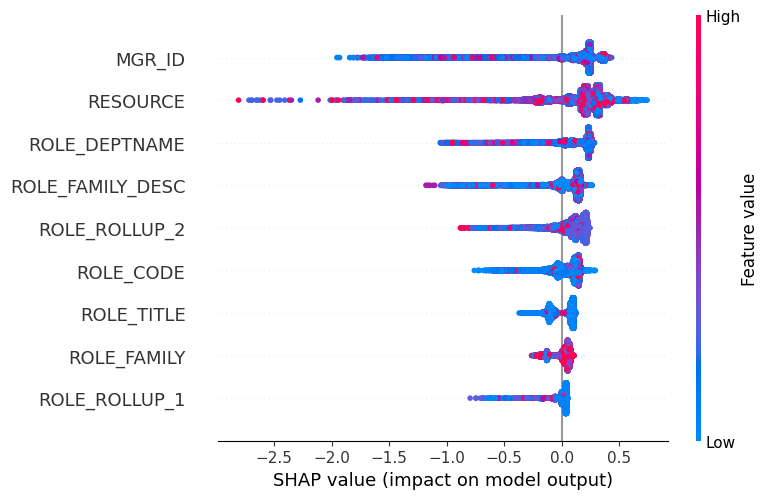

In [65]:
shap.summary_plot(shap_values, X)

Shap-values для конкретного объекта.

In [66]:
shap.initjs()
shap.force_plot(expected_value, shap_values[3, :], X.iloc[3, :])

Сохранение модели

In [67]:
my_best_model = CatBoostClassifier(iterations=10)
my_best_model.fit(
    X_train,
    y_train,
    eval_set=(X_validation, y_validation),
    cat_features=cat_features,
    verbose=False,
)
my_best_model.save_model("catboost_model.bin")
my_best_model.save_model("catboost_model.json", format="json")

In [68]:
my_best_model.load_model("catboost_model.bin")
print(my_best_model.get_params())
print(my_best_model.random_seed_)

{'iterations': 10, 'loss_function': 'Logloss', 'verbose': 0}
0


Подбор гиперпараметров

In [69]:
cat = CatBoostClassifier(n_estimators=50)

grid = {"learning_rate": [0.03, 0.1], "depth": [4, 6, 10]}
#        'l2_leaf_reg': [1, 3, 5, 7, 9]}

grid_search_result = cat.grid_search(
    grid, X=X_train, y=y_train, verbose=False, plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6563227	test: 0.6566072	best: 0.6566072 (0)	total: 13.4ms	remaining: 656ms
1:	learn: 0.6227276	test: 0.6234014	best: 0.6234014 (1)	total: 22.6ms	remaining: 542ms
2:	learn: 0.5915535	test: 0.5927244	best: 0.5927244 (2)	total: 29.7ms	remaining: 466ms
3:	learn: 0.5626485	test: 0.5641488	best: 0.5641488 (3)	total: 33.5ms	remaining: 385ms
4:	learn: 0.5360495	test: 0.5378118	best: 0.5378118 (4)	total: 36.5ms	remaining: 328ms
5:	learn: 0.5116681	test: 0.5137107	best: 0.5137107 (5)	total: 40.3ms	remaining: 296ms
6:	learn: 0.4891786	test: 0.4914464	best: 0.4914464 (6)	total: 43ms	remaining: 264ms
7:	learn: 0.4684688	test: 0.4710067	best: 0.4710067 (7)	total: 46.9ms	remaining: 246ms
8:	learn: 0.4494889	test: 0.4523627	best: 0.4523627 (8)	total: 50.1ms	remaining: 228ms
9:	learn: 0.4317230	test: 0.4348204	best: 0.4348204 (9)	total: 52.6ms	remaining: 211ms
10:	learn: 0.4155908	test: 0.4189671	best: 0.4189671 (10)	total: 57.4ms	remaining: 204ms
11:	learn: 0.4007153	test: 0.4044185	best: 

In [70]:
grid_search_result["params"]

{'depth': 10, 'learning_rate': 0.1}

Визуализация деревьев

In [71]:
# Might run into the graphiz problem:
# https://stackoverflow.com/questions/35064304/runtimeerror-make-sure-the-graphviz-executables-are-on-your-systems-path-aft

In [72]:
cat.plot_tree(tree_idx=0)

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

Хорошее описание гиперпараметров катбуста: https://habr.com/ru/company/otus/blog/527554/

## LightGBM

Особенности LightGBM:

* полиственное (leaf-wise), а не поуровневое (depth-wise) построение деревьев

* быстрое построение дерева, позволяющее не кодировать категориальные признаки, а использовать исходные категории для получения предикатов

* ускорение построения деревьев за счёт бинаризации признаков (объединение значений признака в группы)

Почитать подробнее можно тут: https://medium.com/@pushkarmandot/https-medium-com-pushkarmandot-what-is-lightgbm-how-to-implement-it-how-to-fine-tune-the-parameters-60347819b7fc

In [ ]:
# !conda install lightgbm --y

# For those who strugle with M1/M2 macs:
# !arch -arm64 brew install libomp

In [ ]:
import lightgbm as lgb
import numpy as np
from sklearn.datasets import load_boston
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, train_test_split

data = load_boston()
X_full = data.data
y_full = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=100, random_state=241
)

Обучение

In [ ]:
print("Starting training...")
# train
gbm = lgb.LGBMRegressor(num_leaves=31, learning_rate=0.05, n_estimators=20)
gbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="l1",
    early_stopping_rounds=5,
)

Предсказание и оценка качества

In [ ]:
print("Starting predicting...")

y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)

print("The rmse of prediction is:", mean_squared_error(y_test, y_pred) ** 0.5)

# feature importances
print("Feature importances:", list(gbm.feature_importances_))

Можно задать любую (придумать свою, например) метрику качества

In [ ]:
# self-defined eval metric
# f(y_true: array, y_pred: array) -> name: string, eval_result: float, is_higher_better: bool
# Root Mean Squared Logarithmic Error (RMSLE)
def rmsle(y_true, y_pred):
    return (
        "RMSLE",
        np.sqrt(np.mean(np.power(np.log1p(y_pred) - np.log1p(y_true), 2))),
        False,
    )


print("Starting training with custom eval function...")
# train
gbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=rmsle,
    early_stopping_rounds=5,
)

print("Starting predicting...")
# predict
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)
# eval
print("The rmsle of prediction is:", rmsle(y_test, y_pred)[1])

Подбор гиперпараметров

In [ ]:
# other scikit-learn modules
estimator = lgb.LGBMRegressor(num_leaves=31)

param_grid = {"learning_rate": [0.01, 0.1, 1], "n_estimators": [20, 40]}

gbm = GridSearchCV(estimator, param_grid, cv=3)
gbm.fit(X_train, y_train)

print("Best parameters found by grid search are:", gbm.best_params_)

Предсказание и оценка качества

In [ ]:
pred = gbm.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test, pred)